### Name:
* Geronimo Martinez Nuñez

### Import pip install

In [4]:
%pip install qiskit matplotlib notebook qiskit-aer pylatexenc

     ---------------------------------------- 0.0/162.6 kB ? eta -:--:--
     -- ------------------------------------- 10.2/162.6 kB ? eta -:--:--
     ---- -------------------------------- 20.5/162.6 kB 162.5 kB/s eta 0:00:01
     ------ ------------------------------ 30.7/162.6 kB 186.2 kB/s eta 0:00:01
     ------------- ----------------------- 61.4/162.6 kB 326.1 kB/s eta 0:00:01
     ---------------------------------- - 153.6/162.6 kB 702.7 kB/s eta 0:00:01
     ------------------------------------ 162.6/162.6 kB 695.7 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136928 sha256=63ecc825f9e8b983ceb8969df8d25f


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import modules

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

### Funcion graficadora

In [12]:
def plot_counts(counts, title):
    labels = list(counts.keys())
    values = list(counts.values())
    
    plt.figure(figsize=(6, 4))
    plt.bar(labels, values, color='steelblue')
    plt.title(title)
    plt.xlabel('Estado')
    plt.ylabel('Conteo')
    plt.ylim(0, 1100)
    for i, v in enumerate(values):
        plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('resultado.png', dpi=150)
    plt.show()

## Exercise: Compute the Matrix for a Deutsch Algorithm Function

The Deutsch algorithm is a fundamental quantum algorithm for determining if a given binary function is constant or balanced. In this exercise, you'll be working with one of the possible functions that can be used in the Deutsch algorithm. Your task is to compute the matrix representation of this function and deduce its implementation.

### Background

The Deutsch algorithm deals with functions of the form $f: \{0,1\} \rightarrow \{0,1\}$. There are four possible functions that $f$ can represent:

1. **Constant Zero Function**: $f(0) = 0$ and $f(1) = 0$
2. **Constant One Function**: $f(0) = 1$ and $f(1) = 1$
3. **Balanced Identity Function**: $f(0) = 0$ and $f(1) = 1$
4. **Balanced NOT Function**: $f(0) = 1$ and $f(1) = 0$

### Task

Your task is to compute the matrix representation for the Balanced NOT Function,
$f(x)$, where $f(0) = 1$ and $f(1) = 0$, then use this matrix to deduce the
implementation of the function in terms of quantum gates, and finally simulate
the solution in Python and in IBM's quantum computer

#### Steps:

1. **Matrix Representation**:
   - Determine the matrix representation of the Balanced NOT Function for the Deutsch algorithm. Remember that the function is applied to the qubit in superposition, so consider how the NOT operation affects the basis states $\vert0\rangle$ and $\vert1\rangle$.

2. **Implementation Deduction**:
   - Based on the matrix you've computed, deduce which quantum gates can be used
     to implement the Balanced NOT Function. Consider the effects of standard
     quantum gates (such as X, H, etc.) on the basis states and how they can be
     combined to replicate the function's behavior.
   
3. **Implementation in IBM's QC**:
   - Implemente the experiment for the four functions in IBM's QC.

### Submission Requirements

- **Matrix Computation**: Provide the 2x2 matrix representing the Balanced NOT Function.
- **Gate Implementation**: Describe the sequence of quantum gates that could
  implement this function, including any necessary initial state preparation and
  final measurements.
- **Implementation in IBM's QC**: Show the implementation of the algorithm and
  the graph-bar representation of the output.
- **Explanation**: Briefly explain your reasoning for both the matrix computation and the gate implementation.

### Hints

- Remember that the matrix for a quantum gate operation must reflect how it transforms the standard basis states.
- The Hadamard (H) gate plays a crucial role in creating superpositions necessary for the Deutsch algorithm.
- The NOT operation in quantum computing can be realized using the X gate.

### Evaluation Criteria

- **Accuracy**: Correctness of the matrix representation and quantum gate implementation.
- **Clarity**: Clear and logical explanation of the steps taken to arrive at the solution.
- **Creativity**: Efficient use of quantum gates to achieve the desired function implementation.

Good luck with your task, and remember to approach it step-by-step. This exercise will help you better understand the workings of the Deutsch algorithm and the use of quantum gates in implementing specific functions.


# Deutsch Algorithm — Balanced NOT Function

## Definition of the Function

We consider the balanced NOT function $f: \{0,1\} \rightarrow \{0,1\}$:

$$
f(x) =
\begin{cases}
1 & \text{if } x = 0 \\
0 & \text{if } x = 1
\end{cases}
\qquad \text{i.e.,} \quad f(x) = \neg x
$$

This is balanced because $f(0) \neq f(1)$ — one input maps to 0 and the other to 1.

## Oracle Definition

In the Deutsch algorithm, the oracle acts on a 2-qubit register $|x\rangle|y\rangle$ as:

$$
U_f \, |x,y\rangle = |x,\, y \oplus f(x)\rangle
$$

where $x \in \{0,1\}$ is the input qubit and $y$ is the ancilla qubit.

## Matrix Representation of the Oracle

Evaluating $U_f$ over the full computational basis $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$:

$$
\begin{aligned}
U_f \,|0,0\rangle &= |0,\, 0 \oplus f(0)\rangle = |0,\, 0 \oplus 1\rangle = |0,1\rangle \\
U_f \,|0,1\rangle &= |0,\, 1 \oplus f(0)\rangle = |0,\, 1 \oplus 1\rangle = |0,0\rangle \\
U_f \,|1,0\rangle &= |1,\, 0 \oplus f(1)\rangle = |1,\, 0 \oplus 0\rangle = |1,0\rangle \\
U_f \,|1,1\rangle &= |1,\, 1 \oplus f(1)\rangle = |1,\, 1 \oplus 0\rangle = |1,1\rangle
\end{aligned}
$$

Reading off the column images, the 4×4 unitary matrix is:

$$
U_f =
\begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
$$

The top-left $2\times2$ block swaps $|00\rangle \leftrightarrow |01\rangle$ (ancilla flipped when $x=0$), while the bottom-right block is the identity (ancilla unchanged when $x=1$).

---

<div style="text-align: center;">
    <img src="imgs/img1.png" width="1000"/>
</div>

---

## Gate Implementation

To implement $U_f$ for the balanced NOT function, observe that the ancilla must be flipped **only when $x = 0$**, i.e., when the control qubit is in state $|0\rangle$. A standard CNOT fires on $|1\rangle$, so we sandwich it with X gates on the control:

$$
U_f = (X_0 \otimes I_1)\; \text{CNOT}_{0\to1}\; (X_0 \otimes I_1)
$$

| Step | Gate | Qubit | Effect |
|------|------|-------|--------|
| 1 | X | q[0] | Flips control: $|0\rangle \to |1\rangle$ |
| 2 | CNOT | q[0] → q[1] | Flips ancilla if control is now $|1\rangle$ (i.e., original $x=0$) |
| 3 | X | q[0] | Restores control qubit |

## Full Deutsch Algorithm Circuit

The complete algorithm proceeds as:

| Step | Gate | Qubits | Purpose |
|------|------|--------|---------|
| 1 | X | q[1] | Initialize ancilla in $|1\rangle$ |
| 2 | H | q[0], q[1] | Create superposition + $|-\rangle$ ancilla |
| 3 | X–CNOT–X | q[0], q[1] | Oracle $U_f$ for balanced NOT |
| 4 | H | q[0] | Interference step |
| 5 | Measure | q[0] → c[0] | Read result |

**Expected result:** $|1\rangle$ with 100% probability → function is **balanced**.



Resultados: {'1': 1024}


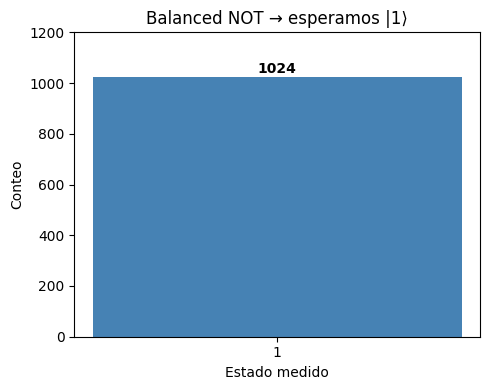

In [17]:
def deutsch_balanced_not():
    qc = QuantumCircuit(2, 1)

    # Step 1: Initialize ancilla in |1⟩
    qc.x(1)

    # Step 2: Hadamard on both qubits
    qc.h(0)
    qc.h(1)

    # Step 3: Oracle — flip ancilla when x=0 (X–CNOT–X)
    qc.x(0)
    qc.cx(0, 1)
    qc.x(0)

    # Step 4: Hadamard on input qubit
    qc.h(0)

    # Step 5: Measure input qubit
    qc.measure(0, 0)

    return qc

qc = deutsch_balanced_not()
qc.draw('mpl')
plt.show()

simulator = AerSimulator()
job = simulator.run(transpile(qc, simulator), shots=1024)
counts = job.result().get_counts()
print("Resultados:", counts)

# Plot results
labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(5, 4))
plt.bar(labels, values, color='steelblue', width=0.4)
plt.title("Balanced NOT → esperamos |1⟩")
plt.xlabel("Estado medido")
plt.ylabel("Conteo")
plt.ylim(0, 1200)
for i, v in enumerate(values):
    plt.text(i, v + 15, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('deutsch_balanced_not.png', dpi=150)
plt.show()


The measurement outcome is $|1\rangle$ with 100% probability, confirming the function is **balanced**. In the Deutsch algorithm, outcome $|1\rangle$ always indicates a balanced function, while $|0\rangle$ would indicate a constant function.

## IBM Quantum Composer — Balanced NOT (Deutsch)

The circuit was executed on IBM Quantum Composer using the statevector simulator with 1024 shots. The implementation uses 2 qubits and 1 classical bit, with the oracle realized via an X–CNOT–X sequence on the input qubit.

The measurement outcome is $|1\rangle$ with 100% probability, confirming that the function is **balanced**. In the Deutsch algorithm, a non-zero measurement result unambiguously identifies a balanced function in a single query.

<div style="text-align: center;">
    <img src="imgs/q1.png" width="1000"/>
</div>


# Exercise: Compute the Matrix for a Balanced Function in the Deutsch-Jozsa Algorithm

The Deutsch-Jozsa algorithm is a cornerstone of quantum computing, demonstrating an exponential speedup over classical algorithms for a specific problem set. This exercise focuses on understanding and implementing a balanced function suitable for the Deutsch-Jozsa algorithm. You will compute the matrix representation of this function and deduce its quantum circuit implementation.

## Background

The Deutsch-Jozsa algorithm distinguishes whether a given function $f: \{0,1\}^n \rightarrow \{0,1\}$ is constant (all outputs the same) or balanced (half of the outputs are 0 and half are 1) with a single quantum query. 

## Task

Choose a balanced function for a 3-qubit system ($n=3$), where the function is defined as balanced if for its eight possible inputs, it produces four 0s and four 1s as output. Compute the matrix representation of this function and deduce the sequence of quantum gates needed to implement it.

### Steps

1. **Function Selection**:
   - Define one constant and two balanced function $f: \{0,1\}^3 \rightarrow
     \{0,1\}$ that you will use for this exercise. An example of a balanced
     function might be a
     function that outputs 1 for inputs $00X$ and $11X$, and 0 for inputs $01X$
     and $10X$.

2. **Matrix Representation**:
   - Calculate the 16x16 unitary matrix that represents $U_f$ for each function on the input states. 

3. **Implementation Deduction**:
   - Based on the computed matrix, determine the sequence of quantum gates that can implement these functions. Your solution should detail the gates used, their order, and how they interact with the qubits to realize the functions.

### Submission Requirements

- **Function Selection**: Clearly state the functions you have chosen to analyze.
- **Matrix Computation**: Provide the matrix that represents the chosen functions.
- **Gate Implementation**: Outline a quantum circuit diagram or describe in
  detail the sequence of quantum gates that implements the chosen function.
- **Simulate the algorithm in Python**: Simulate the execution of the algorithm
  in Python for each function.  
- **Implementation in IBM's QC**: Show the implementation of the algorithm and
  the graph-bar representation of the output.
- **Explanation**: Offer a concise explanation for your approach to defining the function, computing the matrix, and designing the gate implementation.

### Hints

- The Hadamard (H) gate is useful for creating superposition states in the initial step of the Deutsch-Jozsa algorithm.
- The Controlled-NOT (CNOT) gate and other multi-qubit gates may be necessary for implementing balanced functions.
- Remember, the matrix for the quantum operation must be unitary, ensuring the total probability remains 1.

### Evaluation Criteria

- **Accuracy**: The correctness of the matrix representation and the quantum gate sequence.
- **Clarity**: How well the selection process, calculations, and implementation are explained.
- **Creativity**: The efficiency and innovation shown in utilizing quantum gates to replicate the function's behavior.

By completing this exercise, you will gain valuable insights into the operational principles of the Deutsch-Jozsa algorithm and enhance your skills in quantum circuit design.

# Deutsch-Jozsa Algorithm — Constant Function

## Qubit Convention

> **Convención:** Se usa la notación $|x_2 x_1 x_0\rangle$ donde $x_2$ es el bit más significativo (MSB) y $x_0$ es el LSB. Qiskit indexa los qubits en **little-endian**, por lo que el qubit `q[0]` corresponde a $x_2$ y aparece como el bit **derecho** en la cadena de medición. Por ejemplo, el resultado `'000'` significa $q_2=0, q_1=0, q_0=0$.

## Definition of the Function

We consider the constant function:

$$
f(x) = 1 \quad \text{for all } x \in \{000, 001, 010, 011, 100, 101, 110, 111\}
$$

## Oracle Definition

In the Deutsch-Jozsa algorithm, the oracle is defined as:

$$
U_f \, |x,y\rangle = |x,\, y \oplus f(x)\rangle
$$

Since $f(x) = 1$ for all inputs, the oracle always flips the ancilla qubit:

$$
U_f \, |x,y\rangle = |x,\, \overline{y}\rangle
$$

This corresponds to applying an $X$ gate on the ancilla qubit unconditionally, with no control.

## Matrix Representation of the Oracle

Evaluating the transformation over the computational basis $|x_2 x_1 x_0\rangle|y\rangle$ for 3 input qubits + 1 ancilla qubit gives the 16×16 unitary matrix. Every pair $(|x,0\rangle,\, |x,1\rangle)$ is swapped:

$$
U_f = \begin{pmatrix}
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0
\end{pmatrix}
$$

---

<div style="text-align: center;">
    <img src="imgs/img2.png" width="1000"/>
</div>

---

## Gate Implementation

The oracle is implemented with a single $X$ gate on the ancilla qubit `q[3]`, with no control qubits. This unconditional flip realizes $y \mapsto y \oplus 1$ for every input $x$.

Resultados: {'000': 1024}


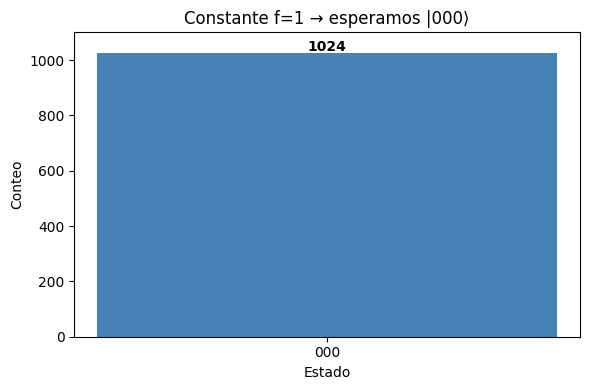

In [14]:
def deutsch_jozsa_constant():
    # 3 input qubits + 1 ancilla + 3 classical bits
    qc = QuantumCircuit(4, 3)

    # Ancilla en |1⟩
    qc.x(3)

    # Hadamard a todos
    qc.h([0, 1, 2, 3])

    # Oracle: f(x) = 1 → X en ancilla (sin control)
    qc.x(3)

    # Hadamard a qubits de entrada
    qc.h([0, 1, 2])

    # Medición
    qc.measure([0, 1, 2], [0, 1, 2])

    return qc

qc = deutsch_jozsa_constant()
qc.draw('mpl')
plt.show()

simulator = AerSimulator()
job = simulator.run(transpile(qc, simulator), shots=1024)
counts = job.result().get_counts()
print("Resultados:", counts)
plot_counts(counts, "Constante f=1 → esperamos |000⟩")

The measurement outcome is $|000\rangle$ with 100% probability, as expected for a constant function. The Deutsch-Jozsa algorithm returns the all-zeros state if and only if the function is constant.

## IBM Quantum Composer — Constant f(x)=1 (Deutsch-Jozsa)

The circuit was executed on IBM Quantum Composer using the statevector simulator with 1024 shots. The implementation uses 4 qubits (3 input + 1 ancilla) and 3 classical bits, with the oracle realized via a single X gate on the ancilla qubit.

The measurement outcome is $|000\rangle$ with 100% probability, confirming that the function is **constant**. The Deutsch-Jozsa algorithm guarantees that the all-zeros state is obtained if and only if the function is constant.

<div style="text-align: center;">
    <img src="imgs/q2.png" width="1000"/>
</div>

# Deutsch-Jozsa Algorithm — Balanced Function 1

## Qubit Convention

> **Convención:** Se usa la notación $|x_2 x_1 x_0\rangle$ donde $x_2$ es el bit más significativo (MSB) y $x_0$ es el LSB. Qiskit indexa los qubits en **little-endian**: `q[0]` $\leftrightarrow$ $x_2$, `q[1]` $\leftrightarrow$ $x_1$, `q[2]` $\leftrightarrow$ $x_0$. En la cadena de medición, `q[0]` aparece como el bit **derecho**. Por ejemplo, `'001'` significa $q_2=0,\, q_1=0,\, q_0=1$, es decir, solo `q[0]` está en $|1\rangle$.

## Definition of the Function

We consider the balanced function $f(x) = x_2$, the most significant bit of the input:

$$
f(x) =
\begin{cases}
0 & \text{if } x \in \{000, 001, 010, 011\} \quad (x_2 = 0) \\
1 & \text{if } x \in \{100, 101, 110, 111\} \quad (x_2 = 1)
\end{cases}
$$

This is balanced because exactly 4 of the 8 inputs produce 0 and 4 produce 1.

## Oracle Definition

In the Deutsch-Jozsa algorithm, the oracle is defined as:

$$
U_f \, |x,y\rangle = |x,\, y \oplus f(x)\rangle
$$

Since $f(x) = x_2$, the ancilla is flipped only when $x_2 = 1$. This is a controlled-NOT with $x_2$ as control and the ancilla as target.

## Matrix Representation of the Oracle

The first 8 rows (where $x_2 = 0$) form the identity — the ancilla is unchanged. The last 8 rows (where $x_2 = 1$) swap each pair $(|x,0\rangle,\, |x,1\rangle)$:

$$
U_f = \begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0
\end{pmatrix}
$$

---

<div style="text-align: center;">
    <img src="imgs/img3.png" width="1000"/>
</div>

---

## Gate Implementation

The oracle is a CNOT gate with `q[0]` as control and `q[3]` (ancilla) as target:

```
cx(0, 3)
```

> **Note on Qiskit convention:** Although $f(x) = x_2$ (the MSB), in Qiskit's little-endian ordering the MSB is assigned to `q[0]`. Therefore `cx(0, 3)` correctly implements the oracle. The measurement result `'001'` reflects that `q[0]=1` appears as the rightmost bit in the output string.




Resultados: {'001': 1024}


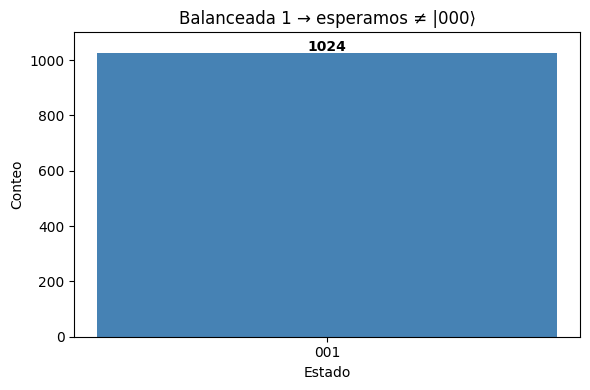

In [15]:
def deutsch_jozsa_balanced1():
    qc = QuantumCircuit(4, 3)

    qc.x(3)             # Ancilla en |1⟩
    qc.h([0, 1, 2, 3])  # Hadamard a todos

    # Oracle: f(x) = x₂ (MSB) → CNOT con control q[0]
    qc.cx(0, 3)

    qc.h([0, 1, 2])           # Hadamard a qubits de entrada
    qc.measure([0, 1, 2], [0, 1, 2])

    return qc

qc = deutsch_jozsa_balanced1()
qc.draw('mpl')
plt.show()

simulator = AerSimulator()
job = simulator.run(transpile(qc, simulator), shots=1024)
counts = job.result().get_counts()
print("Resultados:", counts)
plot_counts(counts, "Balanceada 1 → esperamos ≠ |000⟩")

The measurement outcome is $|001\rangle$ (i.e., `q[0]=1`) with 100% probability — a non-zero state, confirming the function is balanced. The specific state reflects that $f$ depends solely on `q[0]` ($x_2$).

## IBM Quantum Composer — Balanced 1 f(x)=x₂ (Deutsch-Jozsa)

The circuit was executed on IBM Quantum Composer using the statevector simulator with 1024 shots. The implementation uses 4 qubits (3 input + 1 ancilla) and 3 classical bits, with the oracle realized via a single CNOT gate with `q[0]` as control and `q[3]` as target.

The measurement outcome is $|001\rangle$ with 100% probability — a non-zero state, confirming that the function is **balanced**. The specific outcome reflects that $f$ depends solely on the most significant input qubit $x_2$, mapped to `q[0]` in Qiskit's little-endian convention.

<div style="text-align: center;">
    <img src="imgs/q3.png" width="1000"/>
</div>

# Deutsch-Jozsa Algorithm — Balanced Function 2

## Qubit Convention

> **Convención:** Se usa la notación $|x_2 x_1 x_0\rangle$ donde $x_2$ es el MSB y $x_0$ es el LSB. Qiskit indexa los qubits en **little-endian**: `q[0]` $\leftrightarrow$ $x_2$, `q[1]` $\leftrightarrow$ $x_1$, `q[2]` $\leftrightarrow$ $x_0$. En la cadena de medición, `q[2]` aparece como el bit **izquierdo**. Por ejemplo, `'100'` significa $q_2=1,\, q_1=0,\, q_0=0$, es decir, solo `q[2]` está en $|1\rangle$.

## Definition of the Function

We consider the balanced function $f(x) = x_0$, the least significant bit of the input:

$$
f(x) =
\begin{cases}
0 & \text{if } x \in \{000, 010, 100, 110\} \quad (x_0 = 0) \\
1 & \text{if } x \in \{001, 011, 101, 111\} \quad (x_0 = 1)
\end{cases}
$$

This is balanced because exactly 4 of the 8 inputs produce 0 and 4 produce 1.

## Oracle Definition

In the Deutsch-Jozsa algorithm, the oracle is defined as:

$$
U_f \, |x,y\rangle = |x,\, y \oplus f(x)\rangle
$$

Since $f(x) = x_0$, the ancilla is flipped only when $x_0 = 1$. This is a controlled-NOT with $x_0$ as control and the ancilla as target.

## Matrix Representation of the Oracle

The ancilla is flipped for states where $x_0 = 1$ (odd-indexed $x$). Within each group of 4 states sharing the same $(x_2, x_1)$, the pairs with $x_0=0$ are unchanged and the pairs with $x_0=1$ are swapped:

$$
U_f = \begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0
\end{pmatrix}
$$

---

<div style="text-align: center;">
    <img src="imgs/img4.png" width="1000"/>
</div>

---


## Gate Implementation

The oracle is a CNOT gate with `q[2]` as control and `q[3]` (ancilla) as target:

```
cx(2, 3)
```

> **Note on Qiskit convention:** Although $f(x) = x_0$ (the LSB), in Qiskit's little-endian ordering the LSB is assigned to `q[2]`. Therefore `cx(2, 3)` correctly implements the oracle. The measurement result `'100'` reflects that `q[2]=1` appears as the leftmost bit in the output string.



Resultados: {'100': 1024}


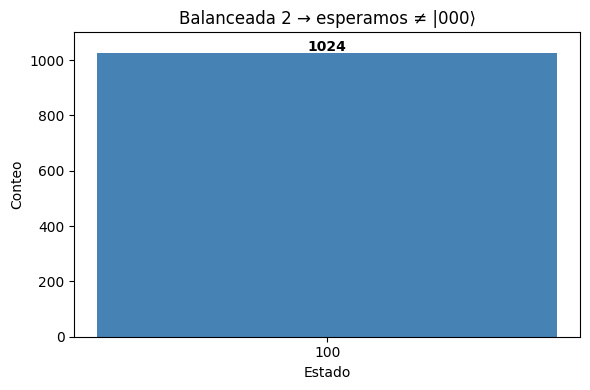

In [16]:
def deutsch_jozsa_balanced2():
    qc = QuantumCircuit(4, 3)

    qc.x(3)             # Ancilla en |1⟩
    qc.h([0, 1, 2, 3])  # Hadamard a todos

    # Oracle: f(x) = x₀ (LSB) → CNOT con control q[2]
    qc.cx(2, 3)

    qc.h([0, 1, 2])           # Hadamard a qubits de entrada
    qc.measure([0, 1, 2], [0, 1, 2])

    return qc

qc = deutsch_jozsa_balanced2()
qc.draw('mpl')
plt.show()

simulator = AerSimulator()
job = simulator.run(transpile(qc, simulator), shots=1024)
counts = job.result().get_counts()
print("Resultados:", counts)
plot_counts(counts, "Balanceada 2 → esperamos ≠ |000⟩")


The measurement outcome is $|100\rangle$ (i.e., `q[2]=1`) with 100% probability — a non-zero state, confirming the function is balanced. The specific state reflects that $f$ depends solely on `q[2]` ($x_0$).

## IBM Quantum Composer — Balanced 2 f(x)=x₀ (Deutsch-Jozsa)

The circuit was executed on IBM Quantum Composer using the statevector simulator with 1024 shots. The implementation uses 4 qubits (3 input + 1 ancilla) and 3 classical bits, with the oracle realized via a single CNOT gate with `q[2]` as control and `q[3]` as target.

The measurement outcome is $|100\rangle$ with 100% probability — a non-zero state, confirming that the function is **balanced**. The specific outcome reflects that $f$ depends solely on the least significant input qubit $x_0$, mapped to `q[2]` in Qiskit's little-endian convention.

<div style="text-align: center;">
    <img src="imgs/q4.png" width="1000"/>
</div>